# Lecture 5: Class demo

## Imports

In [60]:
# import the libraries
import os
import sys
sys.path.append(os.path.join("code"))
from plotting_functions import *
from utils import *

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_val_score, cross_validate, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

%matplotlib inline

pd.set_option("display.max_colwidth", 200)

# c = os.path.join(os.path.abspath(".."), (".."), "data/")
DATA_DIR = os.path.join("data/")
pd.set_option("display.max_colwidth", 200)

<br><br>

## Data and splitting

In [61]:
df = pd.read_csv(DATA_DIR+'cleaned_restaurant_data.csv')

In [62]:
df

,north_america,eat_out_freq,age,n_people,price,food_type,noise_level,good_server,comments,restaurant_name,target
0,Yes,3.0,29,10.0,120.0,Italian,medium,Yes,Ambience,NaN,dislike
1,Yes,2.0,23,3.0,20.0,Canadian/American,no music,No,food tastes bad,NaN,dislike
2,Yes,2.0,21,20.0,15.0,Chinese,medium,Yes,bad food,NaN,dislike
3,No,2.0,24,14.0,18.0,Other,medium,No,Overall vibe on the restaurant,NaN,dislike
4,Yes,5.0,23,30.0,20.0,Chinese,medium,Yes,A bad day,NaN,dislike
...,...,...,...,...,...,...,...,...,...,...,...
959,No,10.0,22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,like
960,Yes,1.0,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,like
961,No,1.0,22,40.0,50.0,Chinese,medium,Yes,The self service sauce table is very clean and the sauces were always filled up.,Haidilao,like
962,Yes,3.0,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,like


In [63]:
df.describe()

,eat_out_freq,age,n_people,price
count,964.000000,964.000000,6.960000e+02,696.000000
mean,2.585187,23.975104,1.439254e+04,1472.179152
std,2.246486,4.556716,3.790481e+05,37903.575636
min,0.000000,10.000000,-2.000000e+00,0.000000
25%,1.000000,21.000000,1.000000e+01,18.000000
50%,2.000000,22.000000,2.000000e+01,25.000000
75%,3.000000,26.000000,3.000000e+01,40.000000
max,15.000000,46.000000,1.000000e+07,1000000.000000


Are there any unusual values in this data that you notice?
Let's get rid of these outliers. 

In [64]:
upperbound_price = 200
lowerbound_people = 1
df = df[~(df['price'] > 200)]
restaurant_df = df[~(df['n_people'] < lowerbound_people)]
restaurant_df.shape

(942, 11)

In [65]:
restaurant_df.describe()

,eat_out_freq,age,n_people,price
count,942.000000,942.000000,674.000000,674.000000
mean,2.598057,23.992569,24.973294,34.023279
std,2.257787,4.582570,22.016660,29.018622
min,0.000000,10.000000,1.000000,0.000000
25%,1.000000,21.000000,10.000000,18.000000
50%,2.000000,22.000000,20.000000,25.000000
75%,3.000000,26.000000,30.000000,40.000000
max,15.000000,46.000000,200.000000,200.000000


We aim to predict whether a restaurant is liked or disliked.

In [66]:
# Separate `X` and `y`. 

X = restaurant_df.drop(columns=['target'])
y = restaurant_df['target']

In [67]:
y.value_counts()

target
like       472
dislike    470
Name: count, dtype: int64

Let's perturbe this data just to demonstrate a few concepts. Don't do it in real life. 

In [68]:
X.at[459, 'food_type'] = 'Quebecois'
X['price'] = X['price'] * 100

In [69]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

<br><br>

## Exploratory data analysis 

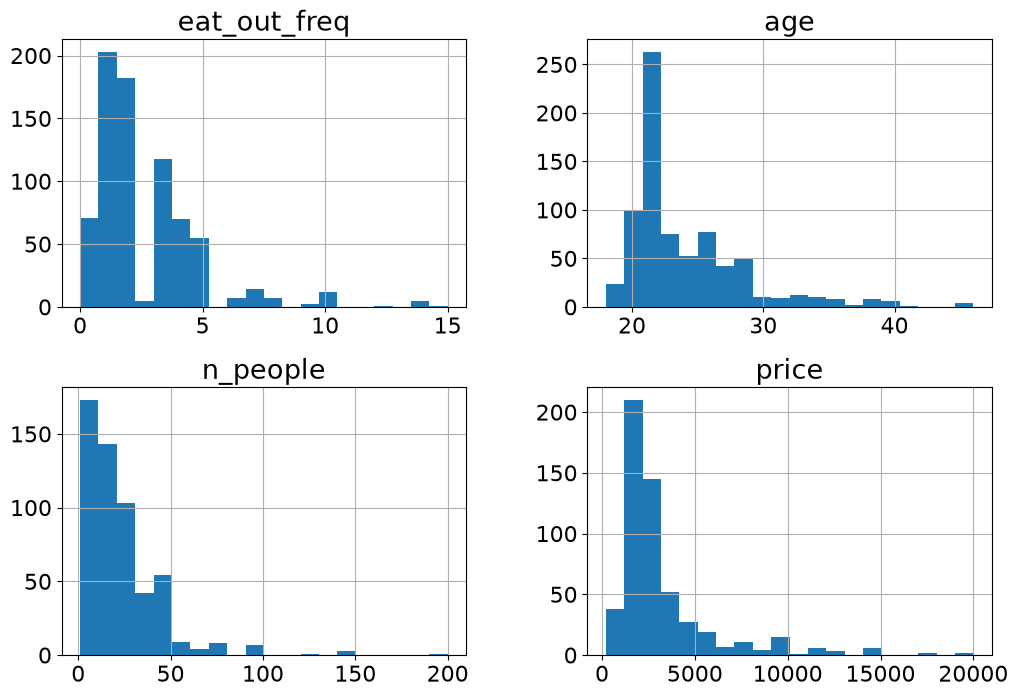

In [70]:
X_train.hist(bins=20, figsize=(12, 8));

Do you see anything interesting in these plots? 

In [71]:
X_train['food_type'].value_counts()

food_type
Other                189
Canadian/American    131
Chinese              102
Indian                36
Italian               32
Thai                  20
Fusion                18
Mexican               17
fusion                 3
Quebecois              1
Name: count, dtype: int64

Error in data collection? Probably "Fusion" and "fusion" categories should be combined?

In [72]:
X_train['food_type'] = X_train['food_type'].replace("fusion", "Fusion")
X_test['food_type'] = X_test['food_type'].replace("fusion", "Fusion")

In [73]:
X_train['food_type'].value_counts()

food_type
Other                189
Canadian/American    131
Chinese              102
Indian                36
Italian               32
Fusion                21
Thai                  20
Mexican               17
Quebecois              1
Name: count, dtype: int64

Again, usually we should spend lots of time in EDA, but let's stop here so that we have time to learn about transformers and pipelines.   

<br><br>

## Modeling 

### Dummy Classifier

In [74]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier()
scores = cross_validate(dummy, X_train, y_train, return_train_score=True)
pd.DataFrame(scores)

,fit_time,score_time,test_score,train_score
0,0.000000,0.003662,0.516556,0.514950
1,0.002705,0.000700,0.516556,0.514950
2,0.003825,0.000000,0.516556,0.514950
3,0.002007,0.000000,0.513333,0.515755
4,0.002007,0.000000,0.513333,0.515755


<br><br>

### Let's try KNN on this data

Do you think KNN would work directly on `X_train` and `y_train`?

In [ ]:
# Preprocessing and pipeline
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

<br><br><br><br><br><br>
- We need to preprocess the data before feeding it into machine learning models. What are the different types of features in the data?
- What transformations are necessary before training a machine learning model?
- Can we categorize features based on the type of transformations they require?

In [76]:
X_train[4:11]

,north_america,eat_out_freq,age,n_people,price,food_type,noise_level,good_server,comments,restaurant_name
62,Yes,2.0,24,20.0,3000.0,Indian,high,Yes,bad taste,east is east
694,No,0.0,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN
890,No,5.0,21,50.0,3500.0,Canadian/American,high,Yes,5,Joeys Shipyards
677,Yes,3.0,20,30.0,2000.0,Mexican,low,Yes,NaN,NaN
161,No,0.0,27,NaN,NaN,NaN,NaN,NaN,NaN,NaN
571,Yes,3.0,22,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11,Yes,2.0,21,30.0,3000.0,Chinese,medium,Yes,food that didn't come,Happy Lamb


In [77]:
numeric_feats = ['age', 'n_people', 'price'] # Continuous and quantitative features
categorical_feats = ['food_type', 'north_america'] # Discrete and qualitative features
binary_feats = ['good_server'] # Categorical features with only two possible values 
ordinal_feats = ['noise_level'] # Some natural ordering in the categories 
noise_cats = ['no music', 'low', 'medium', 'high', 'crazy loud']
drop_feats = ['comments', 'restaurant_name', 'eat_out_freq'] # Dropping text feats and `eat_out_freq` because it's not that useful

In [78]:
X_train.columns

Index(['north_america', 'eat_out_freq', 'age', 'n_people', 'price',
       'food_type', 'noise_level', 'good_server', 'comments',
       'restaurant_name'],
      dtype='str')

In [ ]:
X_train['food_type'].value_counts()

food_type
Other                189
Canadian/American    131
Chinese              102
Indian                36
Italian               32
Fusion                21
Thai                  20
Mexican               17
Quebecois              1
Name: count, dtype: int64

In [ ]:
X_train['north_america'].value_counts()

north_america
Yes                    415
No                     330
Don't want to share      8
Name: count, dtype: int64

In [ ]:
X_train['good_server'].value_counts()

good_server
Yes    396
No     148
Name: count, dtype: int64

In [ ]:
X_train['noise_level'].value_counts()

noise_level
medium        232
low           186
high           75
no music       37
crazy loud     18
Name: count, dtype: int64

In [ ]:
# numeric_feats = ['age', 'n_people', 'price'] # Continuous and quantitative features
# categorical_feats = [] # Discrete and qualitative features
# binary_feats = [] # Categorical features with only two possible values 
# ordinal_feats = [] # Some natural ordering in the categories 
# noise_cats = ['no music', 'low', 'medium', 'high', 'crazy loud']
# drop_feats = ['comments', 'restaurant_name', 'eat_out_freq'] # Dropping text feats and `eat_out_freq` because it's not that useful

<br><br>

Let's begin with numeric features. What if we just use numeric features to train a KNN model? Would it work? 

In [ ]:
X_train_num = X_train[numeric_feats]
X_test_num = X_test[numeric_feats]
knn.fit(X_train_num, y_train)

We need to deal with NaN values. 

### sklearn's `SimpleImputer` 

In [80]:
# Impute numeric features using SimpleImputer
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

# fit the imputer 
imputer.fit(X_train_num)

# Transform training data 
X_train_num_imp = imputer.transform(X_train_num)

# Transform test data 
X_test_num_imp = imputer.transform(X_test_num)

In [81]:
knn.fit(X_train_num_imp, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[object](2,)","['dislike','like']"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


No more errors. It worked! Let's try cross validation. 

In [82]:
knn.score(X_train_num_imp, y_train)

0.6679946879150066

In [83]:
knn.score(X_test_num_imp, y_test)

0.49206349206349204

We have slightly improved results in comparison to the dummy model. 

### Activity: Discuss the following questions as a group

- What's the difference between sklearn estimators and transformers?  
- Can you think of a better way to impute missing values? 

<br><br><br><br>

Do we need to scale the data? 

In [85]:
X_train[numeric_feats]

,age,n_people,price
80,21,30.0,2200.0
934,21,30.0,3000.0
911,20,40.0,2500.0
459,21,NaN,NaN
62,24,20.0,3000.0
...,...,...,...
106,27,10.0,1500.0
333,24,12.0,800.0
393,20,5.0,1500.0
376,20,NaN,NaN


In [86]:
# Scale the imputed data 

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train_num_imp)
X_train_num_imp_scaled = scaler.transform(X_train_num_imp)
X_test_num_imp_scaled = scaler.transform(X_test_num_imp)

### Alternative methods for scaling
- [MinMaxScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html): Transform each feature to a desired range
- [RobustScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.RobustScaler.html): Scale features using median and quantiles. Robust to outliers. 
- [Normalizer](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.Normalizer.html): Works on rows rather than columns. Normalize examples individually to unit norm.
- [MaxAbsScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MaxAbsScaler.html): A scaler that scales each feature by its maximum absolute value.
    - What would happen when you apply `StandardScaler` to sparse data?    
- You can also apply custom scaling on columns using [`FunctionTransformer`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.FunctionTransformer.html). For example, when a column follows the power law distribution (a handful of your values have many data points whereas most other values have few data points) log scaling is helpful.    

- For now, let's focus on `StandardScaler`. Let's carry out cross-validation

In [87]:
cross_val_score(knn, X_train_num_imp_scaled, y_train)

array([0.53642384, 0.51655629, 0.55629139, 0.56666667, 0.54      ])

In this case, we don't see a big difference with `StandardScaler`. But usually, scaling is a good idea. 

<br><br><br><br>
- This worked but are we doing anything wrong here? 
- What's the problem with calling `cross_val_score` with preprocessed data? 


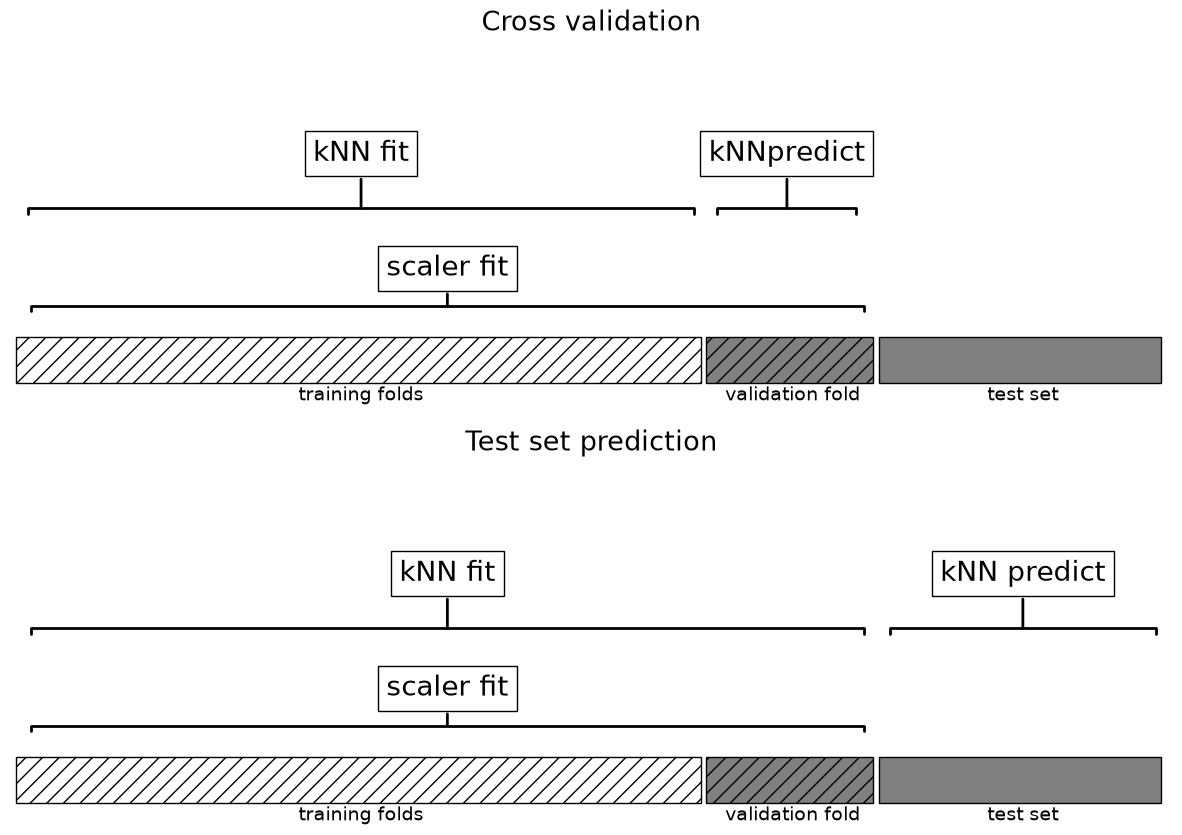

In [ ]:
plot_improper_processing("kNN")

<br><br><br><br>

#### How would you do it properly? Enter sklearn pipelines!!

In [88]:
# Create a pipeline 
pipe_knn = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler(), 
    KNeighborsClassifier()
) 

In [89]:
cross_val_score(pipe_knn, X_train_num, y_train).mean()

np.float64(0.5325916114790287)

- What is happening under the hood? 
- Why is this a better approach? 

<img src='images/pipeline.png' width="800">
    
[Source](https://amueller.github.io/COMS4995-s20/slides/aml-04-preprocessing/#18)

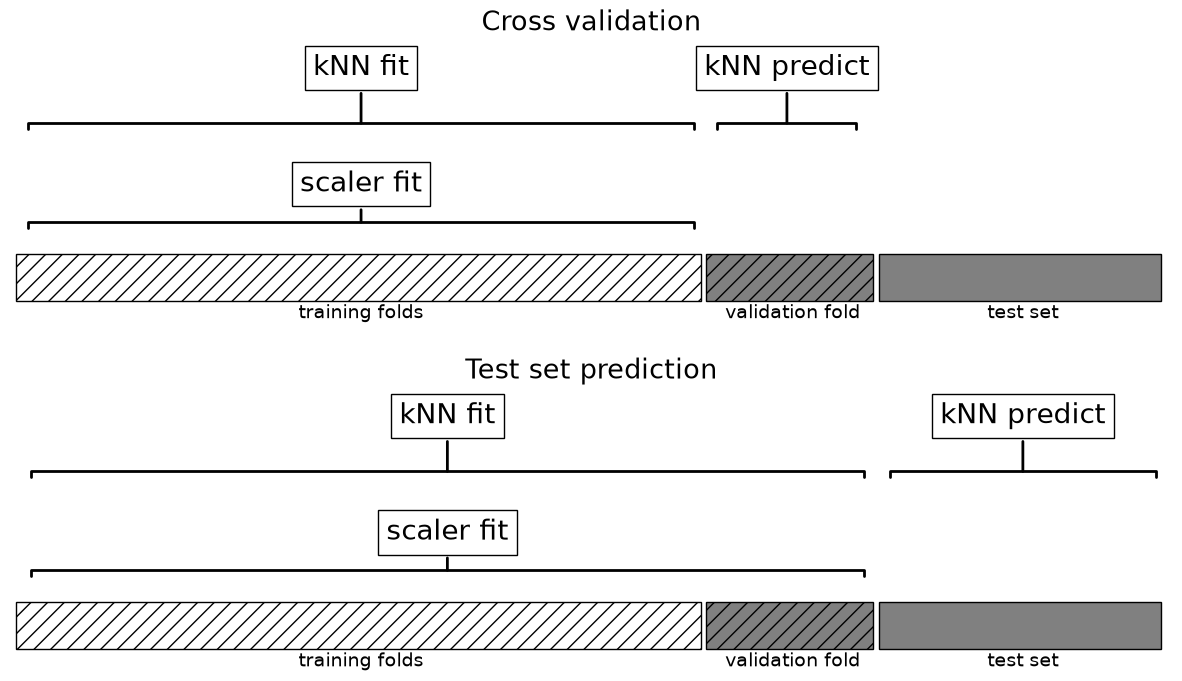

In [ ]:
plot_proper_processing("kNN")

<br><br><br><br>

### Categorical features

Let's assess the scores using categorical features.

In [ ]:
X_train['food_type'].value_counts()

food_type
Other                189
Canadian/American    131
Chinese              102
Indian                36
Italian               32
Fusion                21
Thai                  20
Mexican               17
Quebecois              1
Name: count, dtype: int64

In [90]:
X_train[categorical_feats]

,food_type,north_america
80,Chinese,No
934,Canadian/American,Yes
911,Canadian/American,No
459,Quebecois,Yes
62,Indian,Yes
...,...,...
106,Chinese,No
333,Other,No
393,Canadian/American,Yes
376,NaN,Yes


In [91]:
X_train['north_america'].value_counts()

north_america
Yes                    415
No                     330
Don't want to share      8
Name: count, dtype: int64

In [ ]:
X_train['food_type'].value_counts()

food_type
Other                189
Canadian/American    131
Chinese              102
Indian                36
Italian               32
Fusion                21
Thai                  20
Mexican               17
Quebecois              1
Name: count, dtype: int64

In [92]:
X_train_cat = X_train[categorical_feats]
X_test_cat = X_test[categorical_feats]

In [ ]:
# One-hot encoding of categorical features 
from sklearn.preprocessing import OneHotEncoder
# Create class object
ohe = OneHotEncoder()

# fit OneHotEncoder
ohe.fit(X_train_cat, y_train)

X_train_cat_ohe  = ohe.transform(X_train_cat)# transform the train set
X_test_cat_ohe  =  ohe.transform(X_test_cat)# transform the test set

In [100]:
X_train_cat_ohe

array([[0., 1., 0., ..., 0., 1., 0.],
       [1., 0., 0., ..., 0., 0., 1.],
       [1., 0., 0., ..., 0., 1., 0.],
       ...,
       [1., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 1., 0., ..., 1., 0., 0.]], shape=(753, 13))

In [101]:
display(X_train_cat_ohe[0:10].toarray())

AttributeError: 'numpy.ndarray' object has no attribute 'toarray'

- It's a sparse matrix. 
- Why? What would happen if we pass `sparse_output=False`? Why we might want to do that? 

In [102]:
# Get the OHE feature names 

ohe_feats = ohe.get_feature_names_out().tolist()
ohe_feats

['food_type_Canadian/American',
 'food_type_Chinese',
 'food_type_Fusion',
 'food_type_Indian',
 'food_type_Italian',
 'food_type_Mexican',
 'food_type_Other',
 'food_type_Quebecois',
 'food_type_Thai',
 'food_type_nan',
 "north_america_Don't want to share",
 'north_america_No',
 'north_america_Yes']

In [103]:
pd.DataFrame(X_train_cat_ohe, columns = ohe_feats)

,food_type_Canadian/American,food_type_Chinese,food_type_Fusion,food_type_Indian,food_type_Italian,food_type_Mexican,food_type_Other,food_type_Quebecois,food_type_Thai,food_type_nan,north_america_Don't want to share,north_america_No,north_america_Yes
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
748,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
749,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
750,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
751,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


In [104]:
cross_val_score(knn, X_train_cat_ohe, y_train)

array([0.56291391, 0.53642384, 0.54304636, 0.54666667, 0.55333333])

### Activity: Discuss the following questions in your group

- What's wrong here? 
- How can we fix this?

<br><br><br><br><br><br>

Let's do this properly...

In [105]:
# Code to create a pipeline for OHE and KNN
pipe_ohe_knn = make_pipeline(
    OneHotEncoder(sparse_output=False, handle_unknown="ignore"),
    KNeighborsClassifier()
)

In [106]:
cross_val_score(pipe_ohe_knn, X_train_cat, y_train)

array([0.56291391, 0.53642384, 0.54304636, 0.54666667, 0.55333333])

### Ordinal features

Let's examine the scores using ordinal features.

In [107]:
noise_ordering = ['no music', 'low', 'medium', 'high', 'crazy loud']

In [108]:
X_train['noise_level'].value_counts()

noise_level
medium        232
low           186
high           75
no music       37
crazy loud     18
Name: count, dtype: int64

In [109]:
pipe_ordinal_knn = make_pipeline(
    OrdinalEncoder(categories=[noise_ordering]),
    KNeighborsClassifier()
)

In [110]:
cross_val_score(pipe_ordinal_knn, X_train[['noise_level']], y_train)

ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\babafemi.sorinolu\Downloads\lecture05_demo-main\lecture05_demo-main\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 860, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\babafemi.sorinolu\Downloads\lecture05_demo-main\lecture05_demo-main\.venv\Lib\site-packages\sklearn\base.py", line 1403, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\babafemi.sorinolu\Downloads\lecture05_demo-main\lecture05_demo-main\.venv\Lib\site-packages\sklearn\pipeline.py", line 632, in fit
    Xt = self._fit(
         ^^^^^^^^^^
  File "c:\Users\babafemi.sorinolu\Downloads\lecture05_demo-main\lecture05_demo-main\.venv\Lib\site-packages\sklearn\pipeline.py", line 561, in _fit
    X, fitted_transformer = fit_transform_one_cached(
                            ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\babafemi.sorinolu\Downloads\lecture05_demo-main\lecture05_demo-main\.venv\Lib\site-packages\joblib\memory.py", line 331, in __call__
    return self.func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\babafemi.sorinolu\Downloads\lecture05_demo-main\lecture05_demo-main\.venv\Lib\site-packages\sklearn\pipeline.py", line 1593, in _fit_transform_one_with_callbacks
    Xt, transformer = _fit_transform_one(
                      ^^^^^^^^^^^^^^^^^^^
  File "c:\Users\babafemi.sorinolu\Downloads\lecture05_demo-main\lecture05_demo-main\.venv\Lib\site-packages\sklearn\pipeline.py", line 1566, in _fit_transform_one
    res = transformer.fit_transform(X, y, **params.get("fit_transform", {}))
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\babafemi.sorinolu\Downloads\lecture05_demo-main\lecture05_demo-main\.venv\Lib\site-packages\sklearn\utils\_set_output.py", line 327, in wrapped
    data_to_wrap = f(self, X, *args, **kwargs)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\babafemi.sorinolu\Downloads\lecture05_demo-main\lecture05_demo-main\.venv\Lib\site-packages\sklearn\base.py", line 972, in fit_transform
    return self.fit(X, y, **fit_params).transform(X)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\babafemi.sorinolu\Downloads\lecture05_demo-main\lecture05_demo-main\.venv\Lib\site-packages\sklearn\base.py", line 1403, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\babafemi.sorinolu\Downloads\lecture05_demo-main\lecture05_demo-main\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py", line 1517, in fit
    fit_results = self._fit(
                  ^^^^^^^^^^
  File "c:\Users\babafemi.sorinolu\Downloads\lecture05_demo-main\lecture05_demo-main\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py", line 168, in _fit
    raise ValueError(msg)
ValueError: Found unknown categories [nan] in column 0 during fit


<br><br><br><br><br><br>

In [111]:
X_train['noise_level'].isnull().any()

np.True_

There are missing values. So we need an imputer. 

In [113]:
from sklearn.preprocessing import OrdinalEncoder
noise_ordering = ['no music', 'low', 'medium', 'high', 'crazy loud']

ordinal_transformer = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OrdinalEncoder(categories=[noise_ordering]),
    KNeighborsClassifier()
)

In [114]:
cross_val_score(ordinal_transformer, X_train[['noise_level']], y_train)

array([0.54966887, 0.56953642, 0.57615894, 0.55333333, 0.57333333])

<br><br><br><br>

Right now we are working with numeric and categorical features separately. But ideally when we create a model, we need to use all these features together. 

**Enter column transformer!**

How can we horizontally stack  
- preprocessed numeric features, 
- preprocessed binary features, 
- preprocessed ordinal features, and 
- preprocessed categorical features?

Let's define a column transformer. 

In [115]:
from sklearn.compose import make_column_transformer

numeric_transformer = make_pipeline(SimpleImputer(strategy="median"),
                                    StandardScaler()) 
binary_transformer = make_pipeline(SimpleImputer(strategy="most_frequent"), 
                                    OneHotEncoder(drop="if_binary"))
ordinal_transformer = make_pipeline(SimpleImputer(strategy="most_frequent"), 
                                    OrdinalEncoder(categories=[noise_ordering]))
categorical_transformer = make_pipeline(SimpleImputer(strategy="most_frequent"), 
                                    OneHotEncoder(sparse_output=False, handle_unknown="ignore"))

# Define the column transformer
preprocessor = make_column_transformer(
    (numeric_transformer, numeric_feats),
    (binary_transformer, binary_feats),
    (ordinal_transformer, ordinal_feats),
    (categorical_transformer, categorical_feats),    
    ("drop", drop_feats)    
)


How does the transformed data look like? 

In [116]:
categorical_feats

['food_type', 'north_america']

In [117]:
X_train.shape

(753, 10)

In [118]:
transformed = preprocessor.fit_transform(X_train)
transformed.shape

(753, 17)

In [119]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('pipeline-1', ...), ('pipeline-2', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` a

In [120]:
# Getting feature names from a column transformer
ohe_feat_names = preprocessor.named_transformers_['pipeline-4']['onehotencoder'].get_feature_names_out(categorical_feats).tolist()
ohe_feat_names

['food_type_Canadian/American',
 'food_type_Chinese',
 'food_type_Fusion',
 'food_type_Indian',
 'food_type_Italian',
 'food_type_Mexican',
 'food_type_Other',
 'food_type_Quebecois',
 'food_type_Thai',
 "north_america_Don't want to share",
 'north_america_No',
 'north_america_Yes']

In [121]:
numeric_feats

['age', 'n_people', 'price']

In [122]:
feat_names = numeric_feats + binary_feats + ordinal_feats + ohe_feat_names

In [123]:
transformed

array([[-0.66941678,  0.31029469, -0.36840629, ...,  0.        ,
         1.        ,  0.        ],
       [-0.66941678,  0.31029469, -0.05422496, ...,  0.        ,
         0.        ,  1.        ],
       [-0.89515383,  0.82336432, -0.25058829, ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [-0.89515383, -0.97237936, -0.64331495, ...,  0.        ,
         0.        ,  1.        ],
       [-0.89515383, -0.20277493, -0.25058829, ...,  0.        ,
         0.        ,  1.        ],
       [-0.89515383,  1.33643394, -0.05422496, ...,  1.        ,
         0.        ,  0.        ]], shape=(753, 17))

In [124]:
pd.DataFrame(transformed, columns = feat_names)

,age,n_people,price,good_server,noise_level,food_type_Canadian/American,food_type_Chinese,food_type_Fusion,food_type_Indian,food_type_Italian,food_type_Mexican,food_type_Other,food_type_Quebecois,food_type_Thai,north_america_Don't want to share,north_america_No,north_america_Yes
0,-0.669417,0.310295,-0.368406,0.0,3.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,-0.669417,0.310295,-0.054225,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,-0.895154,0.823364,-0.250588,1.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,-0.669417,-0.202775,-0.250588,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,0.007794,-0.202775,-0.054225,1.0,3.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
748,0.685006,-0.715845,-0.643315,1.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
749,0.007794,-0.613231,-0.918224,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
750,-0.895154,-0.972379,-0.643315,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
751,-0.895154,-0.202775,-0.250588,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


We have new columns for the categorical features. Let's create a pipeline with the preprocessor and SVC. 

In [125]:
from sklearn.svm import SVC 

svc_all_pipe = make_pipeline(preprocessor, SVC()) # create a pipeline with column transformer. 
cross_val_score(svc_all_pipe, X_train, y_train).mean()

np.float64(0.686569536423841)

We are getting better results! 
<br><br><br>

### Incorporating text features 

We haven't incorporated the comments feature into our pipeline yet, even though it holds significant value in indicating whether the restaurant was liked or not.

In [126]:
X_train

,north_america,eat_out_freq,age,n_people,price,food_type,noise_level,good_server,comments,restaurant_name
80,No,2.0,21,30.0,2200.0,Chinese,high,No,The environment was very not clean. The food tasted awful.,NaN
934,Yes,4.0,21,30.0,3000.0,Canadian/American,low,Yes,The building and the room gave a very comfy feeling. Immediately after sitting down it felt like we were right at home.,NaN
911,No,4.0,20,40.0,2500.0,Canadian/American,medium,Yes,I was hungry,Chambar
459,Yes,5.0,21,NaN,NaN,Quebecois,NaN,NaN,NaN,NaN
62,Yes,2.0,24,20.0,3000.0,Indian,high,Yes,bad taste,east is east
...,...,...,...,...,...,...,...,...,...,...
106,No,3.0,27,10.0,1500.0,Chinese,medium,Yes,Food wasn't great.,NaN
333,No,1.0,24,12.0,800.0,Other,medium,Yes,NaN,NaN
393,Yes,4.0,20,5.0,1500.0,Canadian/American,low,No,NaN,NaN
376,Yes,5.0,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Let's create bag-of-words representation of the `comments` feature. But first we need to impute the rows where there are no comments. There is a small complication if we want to put `SimpleImputer` and `CountVectorizer` in a pipeline. 
- `SimpleImputer` takes a 2D array as input and produced 2D array as output. 
- `CountVectorizer` takes a 1D array as input. 

To deal with this, we will use sklearn's `FunctionTransformer` to convert the 2D output of `SimpleImputer` into a 1D array which can be passed to `CountVectorizer` as input. 

In [127]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.feature_extraction.text import CountVectorizer

reshape_for_countvectorizer = FunctionTransformer(lambda X: X.squeeze(), validate=False)
text_transformer = make_pipeline(SimpleImputer(strategy="constant", fill_value="missing"), 
                          reshape_for_countvectorizer, 
                          CountVectorizer(max_features=100, stop_words="english"))
text_pipe = make_pipeline(text_transformer, SVC())
cross_val_score(text_pipe, X_train[['comments']], y_train).mean()

np.float64(0.6440529801324504)

Pretty good scores just with text features! Do we get better scores if we combine all features? Let's define a column transformer which carries out 
- imputation and scaling on numeric features
- imputation and one-hot encoding with `drop="if_binary"` on binary features
- imputation and one-hot encoding with `handle_unknown="ignore"` on categorical features
- imputation, reshaping, and bag-of-words transformation on the text feature

In [128]:
from sklearn.feature_extraction.text import CountVectorizer
text_feat = ['comments']

from sklearn.compose import make_column_transformer

numeric_transformer = make_pipeline(SimpleImputer(strategy="median"),
                                    StandardScaler()) 
binary_transformer = make_pipeline(SimpleImputer(strategy="most_frequent"), 
                                    OneHotEncoder(drop="if_binary"))
ordinal_transformer = make_pipeline(SimpleImputer(strategy="most_frequent"), 
                                    OrdinalEncoder(categories=[noise_ordering]))
categorical_transformer = make_pipeline(SimpleImputer(strategy="most_frequent"), 
                                    OneHotEncoder(sparse_output=False, handle_unknown="ignore"))

preprocessor = make_column_transformer(
    (numeric_transformer, numeric_feats),
    (binary_transformer, binary_feats),    
    (categorical_transformer, categorical_feats),
    (ordinal_transformer, ordinal_feats),
    (text_transformer, text_feat)
)

In [129]:
preprocessor.fit_transform(X_train)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 6385 stored elements and shape (753, 117)>

In [130]:
svc_num_cat_text_pipe = make_pipeline(preprocessor, SVC())
cross_val_score(svc_num_cat_text_pipe, X_train, y_train).mean()

np.float64(0.7078675496688742)

Some improvement when we combine all features! 